<a href="https://colab.research.google.com/github/costpetrides/FAIRMODE-WG5/blob/main/Phase2/Duplication_Test_IDW_Add.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
pip install mplcursors

In [5]:
import xarray as xr
import pandas as pd
import numpy as np


ds = xr.open_dataset("EMEP_yearly_2015.nc")

lat_array = ds["lat"].values
lon_array = ds["lon"].values
pm_model = ds["SURF_ug_PM25_rh50"].isel(time=0).values


stations = pd.read_csv("yearly_PM25_2015.csv")


stations = stations[
    (stations["Latitude"] >= lat_array.min()) &
    (stations["Latitude"] <= lat_array.max()) &
    (stations["Longitude"] >= lon_array.min()) &
    (stations["Longitude"] <= lon_array.max())
].copy()

stations_clean = stations.drop_duplicates(
    subset=["Latitude", "Longitude"],
    keep="first"
).copy()

print("Original stations:", len(stations))
print("After removing duplicates:", len(stations_clean))


lat_idx = np.abs(lat_array[:, None] - stations_clean["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon_array[:, None] - stations_clean["Longitude"].values).argmin(axis=0)

stations_clean["lat_idx"] = lat_idx
stations_clean["lon_idx"] = lon_idx

stations_clean["nearest_grid_lat"] = lat_array[lat_idx]
stations_clean["nearest_grid_lon"] = lon_array[lon_idx]

stations_clean["grid_cell_index"] = list(zip(
    stations_clean["nearest_grid_lon"],
    stations_clean["nearest_grid_lat"]
))


grid_agg = (
    stations_clean.groupby(
        ["lon_idx", "lat_idx",
         "nearest_grid_lon", "nearest_grid_lat", "grid_cell_index"]
    )
    .agg(
        SURF_ug_PM25_rh50=("Average", "mean"),
        n_stations=("Average", "count")
    )
    .reset_index()
)

grid_agg["nearest_SURF_ug_PM25_rh50"] = [
    pm_model[i, j]
    for i, j in zip(grid_agg["lat_idx"], grid_agg["lon_idx"])
]


final_df = grid_agg[[
    "nearest_grid_lon",
    "nearest_grid_lat",
    "grid_cell_index",
    "SURF_ug_PM25_rh50",
    "nearest_SURF_ug_PM25_rh50",
    "n_stations"
]]


final_df.to_csv("PM25_NO_DUPLICATES.csv", index=False)


obs = final_df["SURF_ug_PM25_rh50"].values
mod = final_df["nearest_SURF_ug_PM25_rh50"].values

mask = ~np.isnan(obs) & ~np.isnan(mod)
obs = obs[mask]
mod = mod[mask]

R = np.corrcoef(obs, mod)[0, 1]
R2 = R**2

print(f"R² (Observed vs Model): {R2:.4f}")

Original stations: 947
After removing duplicates: 919
R² (Observed vs Model): 0.4532


In [12]:
import numpy as np
import pandas as pd
import plotly.express as px


dup_mask = stations.duplicated(subset=["Latitude", "Longitude"], keep=False)
duplicates = stations[dup_mask].copy()

print("Number of duplicate records:", len(duplicates))


np.random.seed(42)  # for reproducibility

duplicates["Latitude_j"] = duplicates["Latitude"] + np.random.normal(0, 0.05, len(duplicates))
duplicates["Longitude_j"] = duplicates["Longitude"] + np.random.normal(0, 0.05, len(duplicates))


duplicates["group"] = (
    duplicates["Latitude"].round(5).astype(str) + "_" +
    duplicates["Longitude"].round(5).astype(str)
)


fig = px.scatter_geo(
    duplicates,
    lat="Latitude_j",
    lon="Longitude_j",
    color="Average",
    hover_data={
        "Latitude": True,
        "Longitude": True,
        "Average": True,
        "group": True
    },
    color_continuous_scale="viridis",
    title="Duplicate PM2.5 Stations (All Records Visible with Jitter)"
)

# Map styling
fig.update_layout(
    geo=dict(
        scope="europe",   # remove if global
        showland=True,
        landcolor="rgb(230,230,230)"
    )
)

fig.show()

Number of duplicate records: 56


With Duplicates

In [ ]:
import xarray as xr
import pandas as pd
import numpy as np


ds = xr.open_dataset("EMEP_yearly_2015.nc")

lat_array = ds["lat"].values
lon_array = ds["lon"].values
pm_model = ds["SURF_ug_PM25_rh50"].isel(time=0).values


stations = pd.read_csv("yearly_PM25_2015.csv")


stations = stations[
    (stations["Latitude"] >= lat_array.min()) &
    (stations["Latitude"] <= lat_array.max()) &
    (stations["Longitude"] >= lon_array.min()) &
    (stations["Longitude"] <= lon_array.max())
].copy()

print("Total stations (including duplicates):", len(stations))


# Assign nearest grid cell

lat_idx = np.abs(lat_array[:, None] - stations["Latitude"].values).argmin(axis=0)
lon_idx = np.abs(lon_array[:, None] - stations["Longitude"].values).argmin(axis=0)

stations["lat_idx"] = lat_idx
stations["lon_idx"] = lon_idx

stations["nearest_grid_lat"] = lat_array[lat_idx]
stations["nearest_grid_lon"] = lon_array[lon_idx]

stations["grid_cell_index"] = list(zip(
    stations["nearest_grid_lon"],
    stations["nearest_grid_lat"]
))


# Average per grid cell (duplicates INCLUDED)

grid_agg = (
    stations.groupby(
        ["lon_idx", "lat_idx",
         "nearest_grid_lon", "nearest_grid_lat", "grid_cell_index"]
    )
    .agg(
        SURF_ug_PM25_rh50=("Average", "mean"),
        n_stations=("Average", "count")
    )
    .reset_index()
)


#  Extract model value

grid_agg["nearest_SURF_ug_PM25_rh50"] = [
    pm_model[i, j]
    for i, j in zip(grid_agg["lat_idx"], grid_agg["lon_idx"])
]


#  Final dataframe

final_df = grid_agg[[
    "nearest_grid_lon",
    "nearest_grid_lat",
    "grid_cell_index",
    "SURF_ug_PM25_rh50",
    "nearest_SURF_ug_PM25_rh50",
    "n_stations"
]]



final_df.to_csv("PM25_WITH_DUPLICATES.csv", index=False)


obs = final_df["SURF_ug_PM25_rh50"].values
mod = final_df["nearest_SURF_ug_PM25_rh50"].values

mask = ~np.isnan(obs) & ~np.isnan(mod)
obs = obs[mask]
mod = mod[mask]

R = np.corrcoef(obs, mod)[0, 1]
R2 = R**2

print("Total grid cells:", len(final_df))
print(f"R² (Observed vs Model): {R2:.4f}")

Total stations (including duplicates): 947
Total grid cells: 798
R² (Observed vs Model): 0.4528


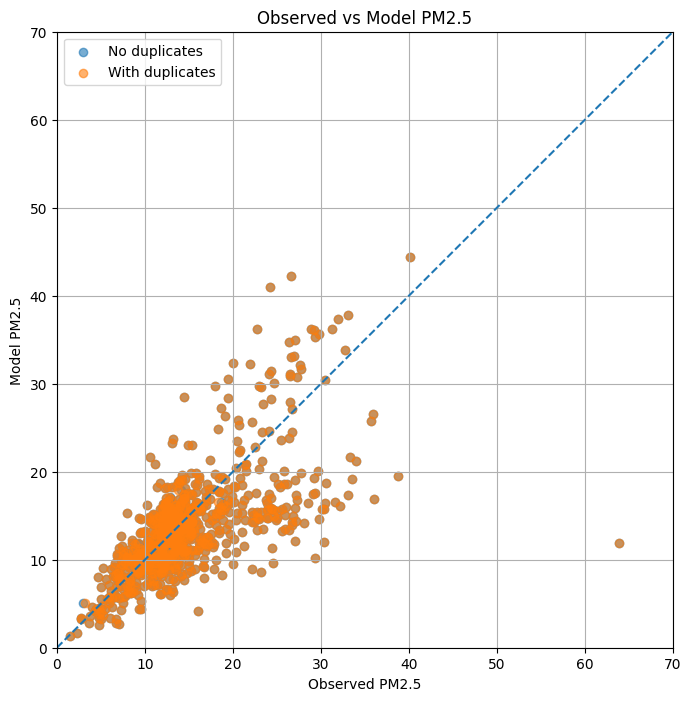

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


df_no_dup = pd.read_csv("PM25_NO_DUPLICATES.csv")
df_with_dup = pd.read_csv("PM25_WITH_DUPLICATES.csv")


obs1 = df_no_dup["SURF_ug_PM25_rh50"].values
mod1 = df_no_dup["nearest_SURF_ug_PM25_rh50"].values

obs2 = df_with_dup["SURF_ug_PM25_rh50"].values
mod2 = df_with_dup["nearest_SURF_ug_PM25_rh50"].values


mask1 = ~np.isnan(obs1) & ~np.isnan(mod1)
mask2 = ~np.isnan(obs2) & ~np.isnan(mod2)

obs1, mod1 = obs1[mask1], mod1[mask1]
obs2, mod2 = obs2[mask2], mod2[mask2]


plt.figure(figsize=(8, 8))

plt.scatter(obs1, mod1, alpha=0.6, label="No duplicates")
plt.scatter(obs2, mod2, alpha=0.6, label="With duplicates")


plt.plot([0, 70], [0, 70], linestyle="--")

plt.xlim(0, 70)
plt.ylim(0, 70)

plt.xlabel("Observed PM2.5")
plt.ylabel("Model PM2.5")

plt.gca().set_aspect('equal', adjustable='box')

plt.legend()
plt.grid(True)
plt.title("Observed vs Model PM2.5")

plt.show()

In [ ]:
import numpy as np
import pandas as pd
import netCDF4 as nc
from tqdm import tqdm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import KFold
import itertools
from sklearn.neighbors import BallTree

# === Load CSV Data ===
csv_file_path = "PM25_NO_DUPLICATES.csv"  # CHANGED
df = pd.read_csv(csv_file_path)

# Compute bias (Observed - Modeled at nearest grid)
df["bias"] = df["SURF_ug_PM25_rh50"] - df["nearest_SURF_ug_PM25_rh50"]

# === Load NetCDF Data ===
netcdf_path = "EMEP_yearly_2015.nc"
dataset = nc.Dataset(netcdf_path, "r")

lon = dataset.variables["lon"][:]
lat = dataset.variables["lat"][:]
pm25_modeled = dataset.variables["SURF_ug_PM25_rh50"][0, :, :]  # (time, lat, lon) -> [0, :, :]

# Convert degrees to radians for Haversine
lon_rad = np.radians(lon)
lat_rad = np.radians(lat)

# Grid points
lon_mesh, lat_mesh = np.meshgrid(lon_rad, lat_rad)
points_grid = np.column_stack([lat_mesh.ravel(), lon_mesh.ravel()])  # (lat, lon) σε radians

# === Station points at nearest grid cells (in radians) ===
station_points = np.column_stack([
    np.radians(df["nearest_grid_lat"].values),
    np.radians(df["nearest_grid_lon"].values)
])
bias_values = df["bias"].values

# === Grid Search for best (p, k) ===
p_values = np.arange(0.1, 5.1, 0.1).tolist()
k_values = np.arange(2, 41, 1).tolist()

kf = KFold(n_splits=10, shuffle=True, random_state=42)
results = []
best_rmse = float("inf")
best_params = None

with tqdm(total=len(p_values) * len(k_values), desc="Grid Search for IDW Additive") as pbar:
    for p, k in itertools.product(p_values, k_values):
        fold_rmses = []
        for train_index, test_index in kf.split(station_points):
            train_points, test_points = station_points[train_index], station_points[test_index]
            train_values, test_values = bias_values[train_index], bias_values[test_index]

            train_tree = BallTree(train_points, metric="haversine")
            predicted_bias = []

            for test_point in test_points:
                dists, idxs = train_tree.query([test_point], k=k)
                dists = dists.flatten()
                idxs = idxs.flatten()

                if np.any(dists == 0):
                    predicted_bias.append(train_values[idxs[dists == 0]][0])
                else:
                    weights = 1 / (dists ** p)
                    weights /= np.sum(weights)
                    interpolated_bias = np.sum(weights * train_values[idxs])
                    predicted_bias.append(interpolated_bias)

            fold_rmse = np.sqrt(mean_squared_error(test_values, predicted_bias))
            fold_rmses.append(fold_rmse)

        mean_rmse = np.mean(fold_rmses)
        results.append((p, k, mean_rmse))
        if mean_rmse < best_rmse:
            best_rmse = mean_rmse
            best_params = (p, k)
        pbar.update(1)

# Save Grid Search Results
results_df = pd.DataFrame(results, columns=["p", "k", "RMSE"])
results_df.to_csv("PM25_NO_DUP_IDW_GridSearch.csv", index=False)  # CHANGED
print(f"\nBest parameters found: p={best_params[0]}, k={best_params[1]} with RMSE={best_rmse:.4f}")

# === Apply IDW with Best Parameters ===
def idw_inverse_distance(grid_points, station_points, values, p, k):
    tree = BallTree(station_points, metric="haversine")
    dists, idxs = tree.query(grid_points, k=k)
    zero_dist_mask = dists == 0
    interpolated = np.zeros(grid_points.shape[0])

    interpolated[zero_dist_mask[:, 0]] = values[idxs[zero_dist_mask[:, 0], 0]]
    non_zero_idx = ~zero_dist_mask[:, 0]
    dists_non_zero = dists[non_zero_idx]
    idxs_non_zero = idxs[non_zero_idx]

    weights = 1 / (dists_non_zero ** p)
    weights /= np.sum(weights, axis=1, keepdims=True)
    interpolated[non_zero_idx] = np.sum(weights * values[idxs_non_zero], axis=1)
    return interpolated

print("\nInterpolating bias field with best hyperparameters...")
interpolated_bias = idw_inverse_distance(points_grid, station_points, bias_values, best_params[0], best_params[1])
interpolated_bias = interpolated_bias.reshape(pm25_modeled.shape)

# === Save Interpolated Bias to NetCDF ===
output_path = "PM25_NO_DUP_IDW.nc"  # CHANGED
new_dataset = nc.Dataset(output_path, "w", format="NETCDF4")
new_dataset.createDimension("lat", lat.shape[0])
new_dataset.createDimension("lon", lon.shape[0])

lat_var = new_dataset.createVariable("lat", "f4", ("lat",))
lon_var = new_dataset.createVariable("lon", "f4", ("lon",))
bias_var = new_dataset.createVariable("Interpolated_Bias", "f4", ("lat", "lon"))

bias_var.setncatts(dataset.variables["SURF_ug_PM25_rh50"].__dict__)
lat_var[:] = lat
lon_var[:] = lon
bias_var[:, :] = interpolated_bias

new_dataset.description = "Interpolated Bias using Inverse Distance Weighting (Optimized p & k, Nearest Grid, Haversine BallTree)"
new_dataset.close()
print("Interpolated Bias Saved to:", output_path)

# === LOSO Validation ===
print("\nComputing LOSO RMSE, MAE, R²...")
loso_predictions = []
loso_actuals = []

for i in tqdm(range(len(station_points)), desc="LOSO Progress"):
    train_points = np.delete(station_points, i, axis=0)
    train_values = np.delete(bias_values, i)
    tree = BallTree(train_points, metric="haversine")
    test_point = station_points[i].reshape(1, -1)
    dists, idxs = tree.query(test_point, k=best_params[1])
    dists = dists.flatten()
    idxs = idxs.flatten()

    if np.any(dists == 0):
        pred = train_values[idxs[dists == 0]][0]
    else:
        weights = 1 / (dists ** best_params[0])
        weights /= np.sum(weights)
        pred = np.sum(weights * train_values[idxs])

    loso_predictions.append(pred)
    loso_actuals.append(bias_values[i])

# Metrics
loso_rmse = np.sqrt(mean_squared_error(loso_actuals, loso_predictions))
loso_mae = mean_absolute_error(loso_actuals, loso_predictions)
loso_r2 = r2_score(loso_actuals, loso_predictions)

print(f"\nLOSO RMSE: {loso_rmse:.4f}")
print(f"LOSO MAE : {loso_mae:.4f}")
print(f"LOSO R²  : {loso_r2:.4f}")

Grid Search for IDW Additive: 100%|██████████| 1950/1950 [04:52<00:00,  6.66it/s]



Best parameters found: p=0.7000000000000001, k=8 with RMSE=3.5197

Interpolating bias field with best hyperparameters...
Interpolated Bias Saved to: PM25_NO_DUP_IDW.nc

Computing LOSO RMSE, MAE, R²...


LOSO Progress: 100%|██████████| 798/798 [00:00<00:00, 955.68it/s]


LOSO RMSE: 3.7162
LOSO MAE : 2.4249
LOSO R²  : 0.4609


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


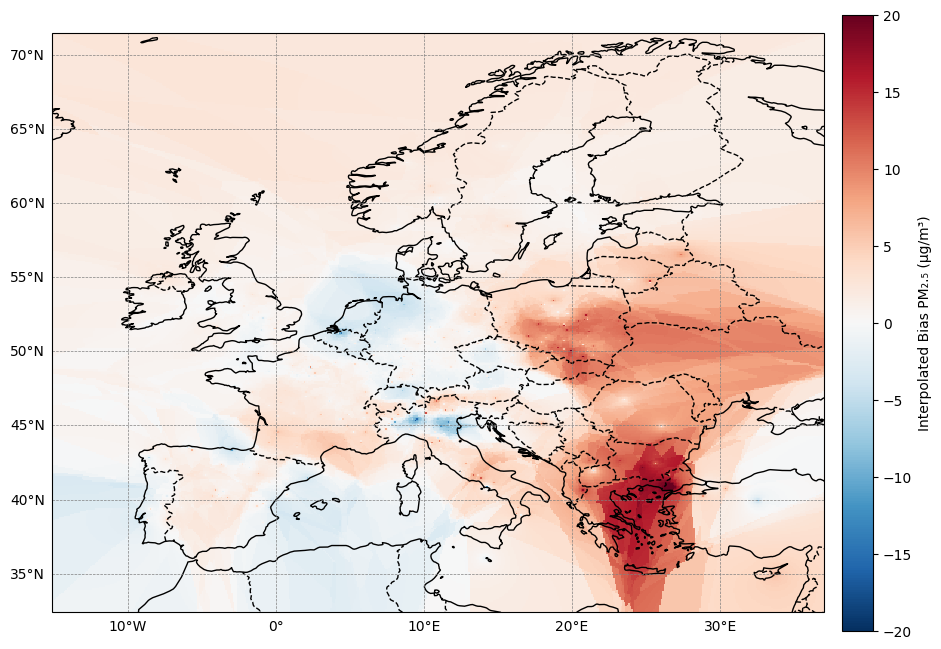

In [ ]:

import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

# === Load the Interpolated Bias NetCDF File ===
bias_netcdf_path = "/content/PM25_NO_DUP_IDW.nc"  # File already saved
ds_bias = xr.open_dataset(bias_netcdf_path)

# Extract interpolated bias (residuals)
interpolated_bias = ds_bias["Interpolated_Bias"].squeeze().values

# Extract coordinates
lon = ds_bias["lon"].values
lat = ds_bias["lat"].values

# === Define Plot Limits (Adjust if needed) ===
cbar_min = -20  # Minimum bias value for color scale
cbar_max = 20  # Maximum bias value for color scale

# Create a plot with Cartopy
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the interpolated bias
im = ax.pcolormesh(lon, lat, interpolated_bias, transform=ccrs.PlateCarree(), cmap="RdBu_r", vmin=cbar_min, vmax=cbar_max, shading='auto')

# Add colorbar
cbar = plt.colorbar(im, orientation="vertical", pad=0.02)
cbar.set_label("Interpolated Bias PM₂.₅ (µg/m³)")

# Add country borders and coastlines
ax.add_feature(cfeature.BORDERS, linestyle="--", edgecolor="black", linewidth=1)
ax.coastlines(resolution="50m", linewidth=1)

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_bias.close()

it should be noted that, for Random Forest regression, duplicated records should be retained. Unlike the previous approach, where stations were aggregated within grid cells, here each grid cell is assigned to its nearest station. This results in a larger training dataset, allowing the model to exploit more observations and potentially improve predictive performance.”

In [ ]:

import netCDF4 as nc
import numpy as np

# === Define File Paths ===
original_nc_path = "EMEP_yearly_2015.nc"
bias_nc_path = "/content/PM25_NO_DUP_IDW.nc"
corrected_nc_path = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"

# === Load the Original Modeled PM₂.₅ NetCDF ===
with nc.Dataset(original_nc_path, "r") as original_nc, nc.Dataset(bias_nc_path, "r") as bias_nc:

    # Load model coordinates and data
    lon = original_nc.variables["lon"][:]
    lat = original_nc.variables["lat"][:]
    time = original_nc.variables["time"][:]
    pm25_original = original_nc.variables["SURF_ug_PM25_rh50"][:]

    # Load the interpolated bias
    interpolated_bias = bias_nc.variables["Interpolated_Bias"][:]

    # === Compute the Unbiased PM₂.₅ ===
    pm25_corrected = pm25_original + interpolated_bias  # Apply the bias correction

    # === Save the Corrected PM₂.₅ to a New NetCDF File ===
    with nc.Dataset(corrected_nc_path, "w", format="NETCDF4") as new_nc:

        # Create dimensions
        new_nc.createDimension("time", None)
        new_nc.createDimension("lat", lat.shape[0])
        new_nc.createDimension("lon", lon.shape[0])

        # Create variables
        time_var = new_nc.createVariable("time", "f4", ("time",))
        lat_var = new_nc.createVariable("lat", "f4", ("lat",))
        lon_var = new_nc.createVariable("lon", "f4", ("lon",))
        pm25_var = new_nc.createVariable("SURF_ug_PM25_rh50_corrected", "f4", ("time", "lat", "lon"), fill_value=-9999.0)

        # Copy attributes from the original PM₂.₅ variable
        pm25_var.setncatts(original_nc.variables["SURF_ug_PM25_rh50"].__dict__)

        # Save data
        time_var[:] = time
        lat_var[:] = lat
        lon_var[:] = lon
        pm25_var[:] = pm25_corrected  # Store corrected PM₂.₅

print(" Bias correction completed successfully!")
print(" Corrected PM₂.₅ NetCDF file saved as:", corrected_nc_path)

 Bias correction completed successfully!
 Corrected PM₂.₅ NetCDF file saved as: BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc


In [ ]:
import netCDF4 as nc
import numpy as np
import shutil

# === Define File Paths ===
input_file = "BaseCase_Corrected_PM25_rh50_Y_IDW_ADD.nc"  # Your original file
output_file = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"  # Renamed final file
jrc_reference_file = "EMEP_yearly_2015.nc"  # JRC reference file

# === Backup Original File Before Modifying ===
shutil.copy(input_file, output_file)

# === Open Original NetCDF and Read Data ===
with nc.Dataset(input_file, "r") as src:

    # Read dimensions
    lon = src.variables["lon"][:]
    lat = src.variables["lat"][:]
    time = src.variables["time"][:]
    o3_data = src.variables["SURF_ug_PM25_rh50_corrected"][:]  # Read O3 data

    # Open new NetCDF file for writing with correct dimension order
    with nc.Dataset(output_file, "w", format="NETCDF4") as dst:

        # === Create Dimensions in Correct Order ===
        dst.createDimension("lon", len(lon))
        dst.createDimension("lat", len(lat))
        dst.createDimension("time", None)  # Keep time as unlimited

        # === Create Variables in Correct Order ===
        lon_var = dst.createVariable("lon", "f4", ("lon",))
        lat_var = dst.createVariable("lat", "f4", ("lat",))
        time_var = dst.createVariable("time", "f4", ("time",))
        o3_var = dst.createVariable("SURF_ug_PM25_rh50", "f4", ("lon", "lat", "time"), fill_value=-9999.0)

        # === Copy Attributes from Original File ===
        for attr in src.ncattrs():
            dst.setncattr(attr, src.getncattr(attr))

        # === Add Missing Global Attributes ===
        jrc_attributes = {
            "vert_coord": "atmosphere_hybrid_sigma_pressure_coordinate",
            "Conventions": "CF-1.6 for coordinates",
            "model": "EMEP_MSC-W",
            "author_of_run": "UoA",
            "created_date": "20250315",
            "created_hour": "091845.466",
            "lastmodified_date": "20241122",
            "lastmodified_hour": "084815.947",
            "projection": "lon lat",
            "period_type": "fullrun",
            "run_label": "Opensource_Setup_2025",
            "history": "Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc",
            "NCO": "netCDF Operators version 5.0.6 (Homepage = http://nco.sf.net, Code = http://github.com/nco/nco)"
        }
        for attr, value in jrc_attributes.items():
            dst.setncattr(attr, value)

        # === Copy Variable Data (Reordered) ===
        lon_var[:] = lon
        lat_var[:] = lat
        time_var[:] = time
        o3_var[:, :, :] = np.transpose(o3_data, (2, 1, 0))  # Reorder from (time, lat, lon) to (lon, lat, time)

print(f" Correction completed! Renamed and fixed NetCDF saved as: {output_file}")

# === Function to Extract NetCDF Structure ===
def get_netcdf_structure(filepath):
    with nc.Dataset(filepath, "r") as dataset:
        structure = {
            "dimensions": {dim: dataset.dimensions[dim].size for dim in dataset.dimensions},
            "variables": {var: dataset.variables[var].dimensions for var in dataset.variables},
            "attributes": {attr: dataset.getncattr(attr) for attr in dataset.ncattrs()}
        }
    return structure

# Extract structures
your_structure = get_netcdf_structure(output_file)
jrc_structure = get_netcdf_structure(jrc_reference_file)

# === Compare Structures ===
print("\n=== DIMENSIONS COMPARISON ===")
print("Your File:", your_structure["dimensions"])
print("JRC File:", jrc_structure["dimensions"])

print("\n=== VARIABLES COMPARISON ===")
print("Your File:", list(your_structure["variables"].keys()))
print("JRC File:", list(jrc_structure["variables"].keys()))

print("\n=== GLOBAL ATTRIBUTES COMPARISON ===")
print("Your File:", your_structure["attributes"])
print("JRC File:", jrc_structure["attributes"])

print(" Final check completed! If all outputs match, your NetCDF is JRC-compliant.")

 Correction completed! Renamed and fixed NetCDF saved as: BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc

=== DIMENSIONS COMPARISON ===
Your File: {'lon': 521, 'lat': 391, 'time': 1}
JRC File: {'time': 1, 'lat': 391, 'lon': 521}

=== VARIABLES COMPARISON ===
Your File: ['lon', 'lat', 'time', 'SURF_ug_PM25_rh50']
JRC File: ['time', 'lat', 'lon', 'SURF_ug_PM25_rh50', 'SURF_ug_NO2', 'SURF_ug_O3']

=== GLOBAL ATTRIBUTES COMPARISON ===
Your File: {'vert_coord': 'atmosphere_hybrid_sigma_pressure_coordinate', 'Conventions': 'CF-1.6 for coordinates', 'model': 'EMEP_MSC-W', 'author_of_run': 'UoA', 'created_date': '20250315', 'created_hour': '091845.466', 'lastmodified_date': '20241122', 'lastmodified_hour': '084815.947', 'projection': 'lon lat', 'period_type': 'fullrun', 'run_label': 'Opensource_Setup_2025', 'history': 'Tue Jan 7 14:58:25 2025: ncrcat -v lon,lat,SURF_ug_PM25_rh50 EMEP45_CAMS61_WG5_Fairmode_BC_Perturbed_fullrun.nc BaseCase_PERT_PM25_YEARLY.nc', 'NCO': 'netCDF Operators versio

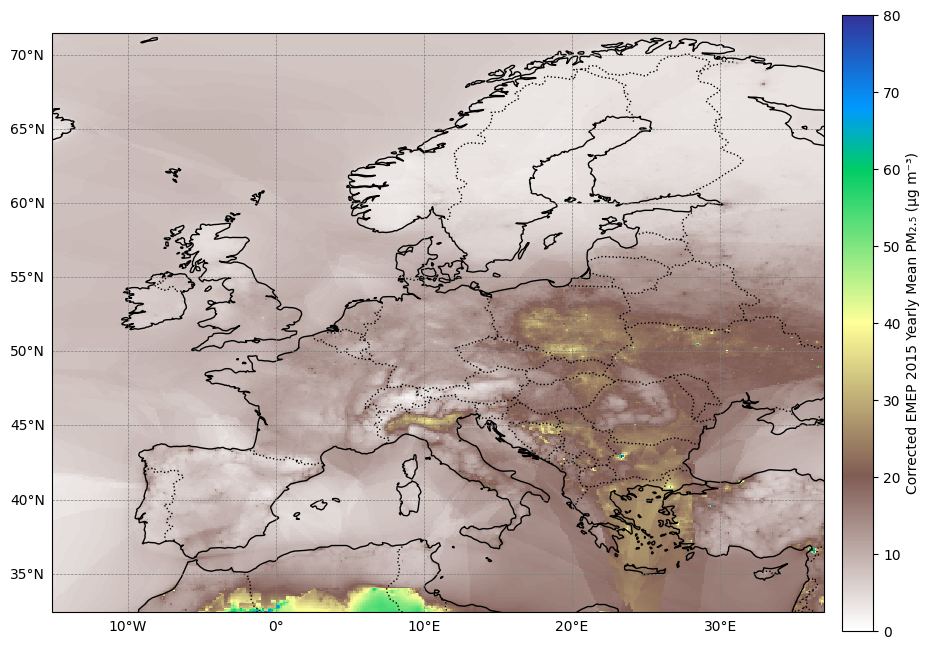

In [ ]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors
import numpy as np

# === Load the Corrected O₃ NetCDF File ===
corrected_netcdf_path = "BaseCase_UoA_PM25_SCA.Cell.Add.IDW_CORR_YEARLY.nc"
ds_corrected = xr.open_dataset(corrected_netcdf_path)

# Extract corrected O₃ values
corrected_o3 = ds_corrected["SURF_ug_PM25_rh50"].squeeze().values.T


# Extract coordinates
lon = ds_corrected["lon"].values
lat = ds_corrected["lat"].values

# Create a 2D meshgrid for lon & lat
Lon, Lat = np.meshgrid(lon, lat)

# === Define Logarithmic Scale for Color Normalization ===
norm = mcolors.Normalize(0, 80)  # Log scale between 1 and max value (adjust if needed)

# Create a figure with a map projection
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})

# Plot the O₃ concentration using pcolormesh with logarithmic scaling
mesh = ax.pcolormesh(Lon, Lat, corrected_o3, cmap='terrain_r', shading='auto', transform=ccrs.PlateCarree(), norm=norm)

# Add a colorbar with logarithmic scaling
cbar = plt.colorbar(mesh, orientation="vertical", pad=0.02)
cbar.set_label("Corrected EMEP 2015 Yearly Mean PM₂.₅ (μg m⁻³)")

# Add coastlines and borders for context
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Add gridlines and labels for longitude and latitude
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=0.5, color="gray")
gl.top_labels = False  # Remove top labels
gl.right_labels = False  # Remove right-side labels

# Set title and labels
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# Show the plot
plt.show()

# Close dataset
ds_corrected.close()